# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнил(а):

    Ахметгалиева Диляра

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [228]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [135]:
RANDOM_STATE = 42

In [136]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

`Если их не зафиксировать, то при перезапуске может что-то сломаться, а нам надо, чтобы случайность зафиксировалась и мы смогли это в любой момент воспроизвести`

## Часть 1 | EDA




Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [137]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [138]:
#проверка df_train на наличие пропусков
df_train.isnull().sum()


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,202
engine,202


In [139]:
#вывод названия колонок в df_train с пропусками
df_train.columns[df_train.isnull().sum() > 0]

Index(['mileage', 'engine', 'max_power', 'torque', 'seats'], dtype='object')

In [140]:
#проверка df_train на наличие дубликатов
df_train.duplicated().sum()

np.int64(985)

In [141]:
#вывод датафрейма из df_train с дубликатами
df_train[df_train.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
254,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
258,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
325,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
326,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6880,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37 kmpl,1461 CC,108.45 bhp,240Nm@ 1750rpm,5.0
6881,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09 kmpl,1248 CC,88.50 bhp,200Nm@ 1750rpm,5.0
6989,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
6997,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [142]:
#проверка df_test на наличие пропусков
df_test.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,19
engine,19


In [143]:
#вывод названия колонок в df_test с пропусками
df_test.columns[df_test.isnull().sum() > 0]

Index(['mileage', 'engine', 'max_power', 'torque', 'seats'], dtype='object')

In [144]:
#проверка df_test на наличие дубликатов
df_test.duplicated().sum()

np.int64(62)

In [145]:
#вывод датафрейма из df_test с дубликатами
df_test[df_test.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
200,Maruti Swift AMT VVT VXI,2019,650000,5621,Petrol,Trustmark Dealer,Automatic,First Owner,22.0 kmpl,1197 CC,81.80 bhp,113Nm@ 4200rpm,5.0
235,Hyundai Grand i10 1.2 CRDi Sportz,2017,450000,56290,Diesel,Dealer,Manual,First Owner,24.0 kmpl,1186 CC,73.97 bhp,190.24nm@ 1750-2250rpm,5.0
238,Toyota Camry 2.5 Hybrid,2016,2000000,68089,Petrol,Trustmark Dealer,Automatic,First Owner,19.16 kmpl,2494 CC,157.7 bhp,213Nm@ 4500rpm,5.0
253,Tata Safari Storme EX,2015,503000,110000,Diesel,Individual,Manual,First Owner,14.1 kmpl,2179 CC,147.94 bhp,320Nm@ 1500-3000rpm,7.0
269,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,Mercedes-Benz S-Class S 350 CDI,2017,6000000,37000,Diesel,Dealer,Automatic,First Owner,13.5 kmpl,2987 CC,254.79 bhp,620Nm@ 1600-2400rpm,5.0
936,BMW X4 M Sport X xDrive20d,2019,5500000,8500,Diesel,Dealer,Automatic,First Owner,16.78 kmpl,1995 CC,190 bhp,400Nm@ 1750-2500rpm,5.0
949,Toyota Camry 2.5 Hybrid,2016,2000000,68089,Petrol,Trustmark Dealer,Automatic,First Owner,19.16 kmpl,2494 CC,157.7 bhp,213Nm@ 4500rpm,5.0
971,Maruti Ertiga SHVS ZDI Plus,2017,750000,50000,Diesel,Individual,Manual,First Owner,24.52 kmpl,1248 CC,88.5 bhp,200Nm@ 1750rpm,7.0


In [ ]:
!pip install ydata-profiling

In [ ]:
#делаем дашборд на основе данных их df_train (удалила аутпут, иначе не рендерится в гите)
from ydata_profiling import ProfileReport
ProfileReport(df_train).to_notebook_iframe()

In [ ]:
#делаем дашборд на основе данных их df_test (удалила аутпут, иначе не рендерится в гите)
ProfileReport(df_test).to_notebook_iframe()

Выявлено, что стоимость (наша целевая переменная) сильно связана с типом трансмиссии и годом выпуска. Год выпуска, в свою очередь, сильно влияет на пробег. Если посмотреть на облако слов, наиболее часто в подборке встречаются huyndai, toyota и honda. Самый частый год выпуска - 2013. Средняя цена 639515.2, что не очень показательно, так как в подборке есть машины за 29999 и 10000000. В селлерах очень большой дисбаланс, это может сильно повлиять на качество предсказания. Большинство машин с механической коробкой передач (возможно, это связано с тем, что в подборке машины до 2020 года). Больше всего классических пятиместок.

### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [149]:
#cчитаем основные статистики по числовым столбцам для df_train
df_train.describe(include='number')

,year,selling_price,km_driven,seats
count,6999.000000,6.999000e+03,6.999000e+03,6797.000000
mean,2013.818403,6.395152e+05,6.958462e+04,5.419008
std,4.053095,8.089419e+05,5.772400e+04,0.965767
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [150]:
#cчитаем основные статистики по категориальным столбцам для df_train
df_train.describe(include='object')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6999,6999,6999,6999,6999,6797,6797,6803,6796
unique,1924,4,3,2,5,386,120,316,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,116,3793,5826,6095,4587,197,885,330,468


In [151]:
#cравниваем среднее и медиану внутри df_train
df_train.describe().loc[['mean', '50%']]

,year,selling_price,km_driven,seats
mean,2013.818403,639515.197171,69584.615517,5.419008
50%,2015.000000,450000.000000,60000.000000,5.000000


In [152]:
#cчитаем основные статистики по числовым столбцам для df_test
df_test.describe(include='number')

,year,selling_price,km_driven,seats
count,1000.000000,1.000000e+03,1000.000000,981.000000
mean,2013.681000,6.179010e+05,71393.341000,5.410805
std,4.012149,7.585539e+05,48486.218662,0.919985
min,1995.000000,3.100000e+04,1303.000000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,9.000000


In [153]:
#cчитаем основные статистики по категориальным столбцам для df_test
df_test.describe(include='object')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


In [154]:
#cравниваем среднее и медиану внутри df_test
df_test.describe().loc[['mean', '50%']]

,year,selling_price,km_driven,seats
mean,2013.681,617901.042,71393.341,5.410805
50%,2014.000,434999.000,61500.000,5.000000


В df_train у года среднее значение меньше, чем медиана, значит, у нас левосторонее распределение, сдвиг в сторону больших значений, что было видно еще на первом этапе (на гистограмме было мало значений до 2005 года и почти все лежат с 2005 по 2020). А в стоимости, пробеге и количестве мест, наоборот, среднее больше, это значит, что есть "выбросы", аномально большие значения, которые тянут на себя среднее.
В df_test ситуация аналогиная, но там отличие меньше. Получается, выборки были разделены репрезентативно. То есть если обучим модель на df_train, она должна будет хорошо себя показать на df_test. Однако сдвиг данных все-таки имеется, поэтому ошибка может возрасти

### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [155]:
#убираем целевую переменную из df_train
df_train_filtred = df_train.drop(columns=['selling_price'])

In [156]:
#отображаем объекты с дубликатами
df_train_filtred[df_train_filtred.duplicated()]

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
254,Hyundai Grand i10 Sportz,2017,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
258,Maruti Swift VXI,2012,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
268,Maruti Swift Dzire VXI,2014,70000,Petrol,Individual,Manual,Second Owner,19.1 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
325,Lexus ES 300h,2019,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6947,Chevrolet Spark 1.0 LS,2010,60000,Petrol,Individual,Manual,Second Owner,18.0 kmpl,995 CC,62 bhp,90.3Nm@ 4200rpm,5.0
6984,Ford Freestyle Titanium Plus Diesel BSIV,2018,24000,Diesel,Individual,Manual,First Owner,24.4 kmpl,1498 CC,98.63 bhp,215Nm@ 1750-3000rpm,5.0
6989,Maruti Swift Dzire VDI,2015,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
6997,Tata Indigo CR4,2013,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [157]:
#считаем количество дубликатов
df_train_filtred.duplicated().sum()

np.int64(1159)

In [158]:
#отбираем названия столбцов из отфильтрованного датасета, где нет целевой переменной, удаляем дубликаты, исключая первые вхождения
cols = df_train_filtred.columns
df_train = df_train.drop_duplicates(subset=cols, keep='first')

In [159]:
#обновляем индексы, чтобы они шли от нуля без пропусков
df_train = df_train.reset_index(drop=True)

In [160]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [161]:
def cleaner(df):
    #обработываем простые числовые столбцы (mileage, engine, max_power)
    cols_to_clean = ['mileage', 'engine', 'max_power']
    for col in cols_to_clean:
        if df[col].dtype == object: #это я добавила, чтобы при случайном перезапуске этой ячейки, всё не сломалось, так как объекты станут float и проверку на object уже не пройдут
            df[col] = (df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan).replace('nan', np.nan).astype(float))

    #обрабатываем torque
    if 'torque' in df.columns and df['torque'].dtype == object:
        s = df['torque'].astype(str).str.lower().str.replace(',', '', regex=False)
        is_kgm = s.str.contains('kgm', na=False)
        extracted_torque = s.str.extract(r'(\d+\.?\d*)')[0].astype(float)
        df['max_torque_rpm'] = s.str.findall(r'\d+').str[-1].astype(float)
        df['torque'] = extracted_torque
        df.loc[is_kgm, 'torque'] *= 9.8
        df.loc[s.eq('nan'), ['torque', 'max_torque_rpm']] = np.nan

    return df

df_train = cleaner(df_train)
df_test = cleaner(df_test)

In [162]:
#прогоним пару раз через sample, чтобы убедиться, что все ок
df_train.sample(30)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_torque_rpm
4582,Mahindra Xylo D2 BS IV,2010,465000,77088,Diesel,Individual,Manual,First Owner,14.00,2489.0,95.00,220.00,8.0,2600.0
177,Maruti Wagon R LXI CNG,2016,360000,50000,CNG,Individual,Manual,First Owner,26.60,998.0,58.16,77.00,5.0,3500.0
167,Mahindra KUV 100 mFALCON G80 K8,2016,450000,15000,Petrol,Individual,Manual,Second Owner,18.15,1198.0,82.00,115.00,6.0,3600.0
3722,Ford Ecosport 1.5 Diesel Titanium,2016,725000,30000,Diesel,Individual,Manual,First Owner,21.70,1498.0,98.96,215.00,5.0,2500.0
2339,Maruti Ritz VDi,2010,220000,100000,Diesel,Individual,Manual,First Owner,21.10,1248.0,73.90,113.00,5.0,4500.0
1047,Mahindra Ssangyong Rexton RX7,2013,800000,117000,Diesel,Dealer,Automatic,First Owner,11.18,2696.0,184.00,402.00,7.0,3000.0
4676,Volkswagen CrossPolo 1.5 TDI,2014,300000,84000,Diesel,Individual,Manual,Second Owner,20.14,1498.0,88.50,230.00,5.0,2500.0
3955,Maruti 800 AC LPG,2008,149000,87540,LPG,Individual,Manual,Third Owner,16.60,796.0,35.50,55.86,5.0,2500.0
2534,Chevrolet Tavera Neo 3 LS 10 Seats BSIII,2015,580000,110000,Diesel,Individual,Manual,Second Owner,13.58,2499.0,72.40,171.00,10.0,1800.0
1501,Hyundai EON Sportz,2018,444000,15000,Petrol,Individual,Manual,First Owner,21.10,814.0,55.20,74.50,5.0,4000.0


In [163]:
#проверим, стали ли типы float
df_train.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage,float64
engine,float64


К сожалению, я не смогу написать промпт, потому что мы с гпт примерно четыре часа разбирали это задание)) от "что значит "115Nm@ 3500-3600rpm"?", где мне объяснили каждую величину, "как ивзлечь и какое регулярное выражение использовать?", "а там еще есть Kgm, что с этим делать, какую лучше единицу измерения выбрать и как перевести в другую единицу измерения?" и так очень долго) Сначала вообще пыталась через replace всё сделать, но кучу раз упало с ошибкой, сдалась

### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [164]:
#заполняем пропуски медианами для df_train и df_test
df_train['mileage'] = df_train['mileage'].fillna(df_train['mileage'].median())
df_train['engine'] = df_train['engine'].fillna(df_train['engine'].median())
df_train['max_power'] = df_train['max_power'].fillna(df_train['max_power'].median())
df_train['torque'] = df_train['torque'].fillna(df_train['torque'].median())
df_train['seats'] = df_train['seats'].fillna(df_train['seats'].median())
df_train['max_torque_rpm'] = df_train['max_torque_rpm'].fillna(df_train['max_torque_rpm'].median())

df_test['mileage'] = df_test['mileage'].fillna(df_train['mileage'].median())
df_test['engine'] = df_test['engine'].fillna(df_train['engine'].median())
df_test['max_power'] = df_test['max_power'].fillna(df_train['max_power'].median())
df_test['torque'] = df_test['torque'].fillna(df_train['torque'].median())
df_test['seats'] = df_test['seats'].fillna(df_train['seats'].median())
df_test['max_torque_rpm'] = df_test['max_torque_rpm'].fillna(df_train['max_torque_rpm'].median())

In [165]:
#проверяем пропуски в df_train
df_train.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [166]:
#проверяем пропуски в df_test
df_test.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


`Медиана менее чувствительна к выбросам, а мы уже убедились ранее, что у нас есть выбросы и распределения не являются в полной мере нормальными. Поэтому в данном случае лучше использовать медиану, а не среднее. Медиану считаем только по тренировочным данным, иначе будет утечка данных и наша модель переобучится, что сделает тест менее эффективным для проверки качества`



### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [167]:
#приводим engine и seats к int в df_train и df_test
df_train['engine'] = df_train['engine'].astype(int)
df_train['seats'] = df_train['seats'].astype(int)

df_test['engine'] = df_test['engine'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

`Seats можно рассмотреть как категориальную переменную, потому что количество мест - это органиченное количество целых значений, которые больше полезны не с точки зрения "2 места больше, чем 4 места", а с точки зрения группировки по отдельным категориям - двухместный автомобиль, пятиместка, семиместка и так далее`

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [168]:
#вызываем describe для df_train
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,175.919680,5.426712,3038.631507
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,116.714313,0.982344,918.277038
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,47.040000,2.000000,400.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,111.800000,5.000000,2250.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,160.000000,5.000000,3000.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,200.000000,5.000000,4000.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,3724.000000,14.000000,21800.000000


In [169]:
#вызываем describe для df_test
df_test.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.33881,1454.87600,90.841670,177.608530,5.403000,3078.456000
std,4.012149,7.585539e+05,48486.218662,3.95175,521.99574,34.893389,103.711762,0.912921,903.502756
min,1995.000000,3.100000e+04,1303.000000,0.00000,624.00000,34.200000,48.000000,4.000000,400.000000
25%,2011.000000,2.500000e+05,37000.000000,16.55000,1197.00000,69.000000,111.700000,5.000000,2500.000000
50%,2014.000000,4.349990e+05,61500.000000,19.37000,1248.00000,82.425000,160.000000,5.000000,3000.000000
75%,2017.000000,6.700000e+05,100000.000000,22.30000,1582.00000,102.000000,205.000000,5.000000,4000.000000
max,2020.000000,6.000000e+06,375000.000000,32.26000,3604.00000,280.000000,1421.000000,9.000000,5200.000000


`Да, это видно по приближению медианы к среднему значению. Так как теперь больше значений стали медианой, то среднее подтянулось и распределение стало более "нормальным", также больше значений в районе медины уменьгают стандартное отклонение`

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

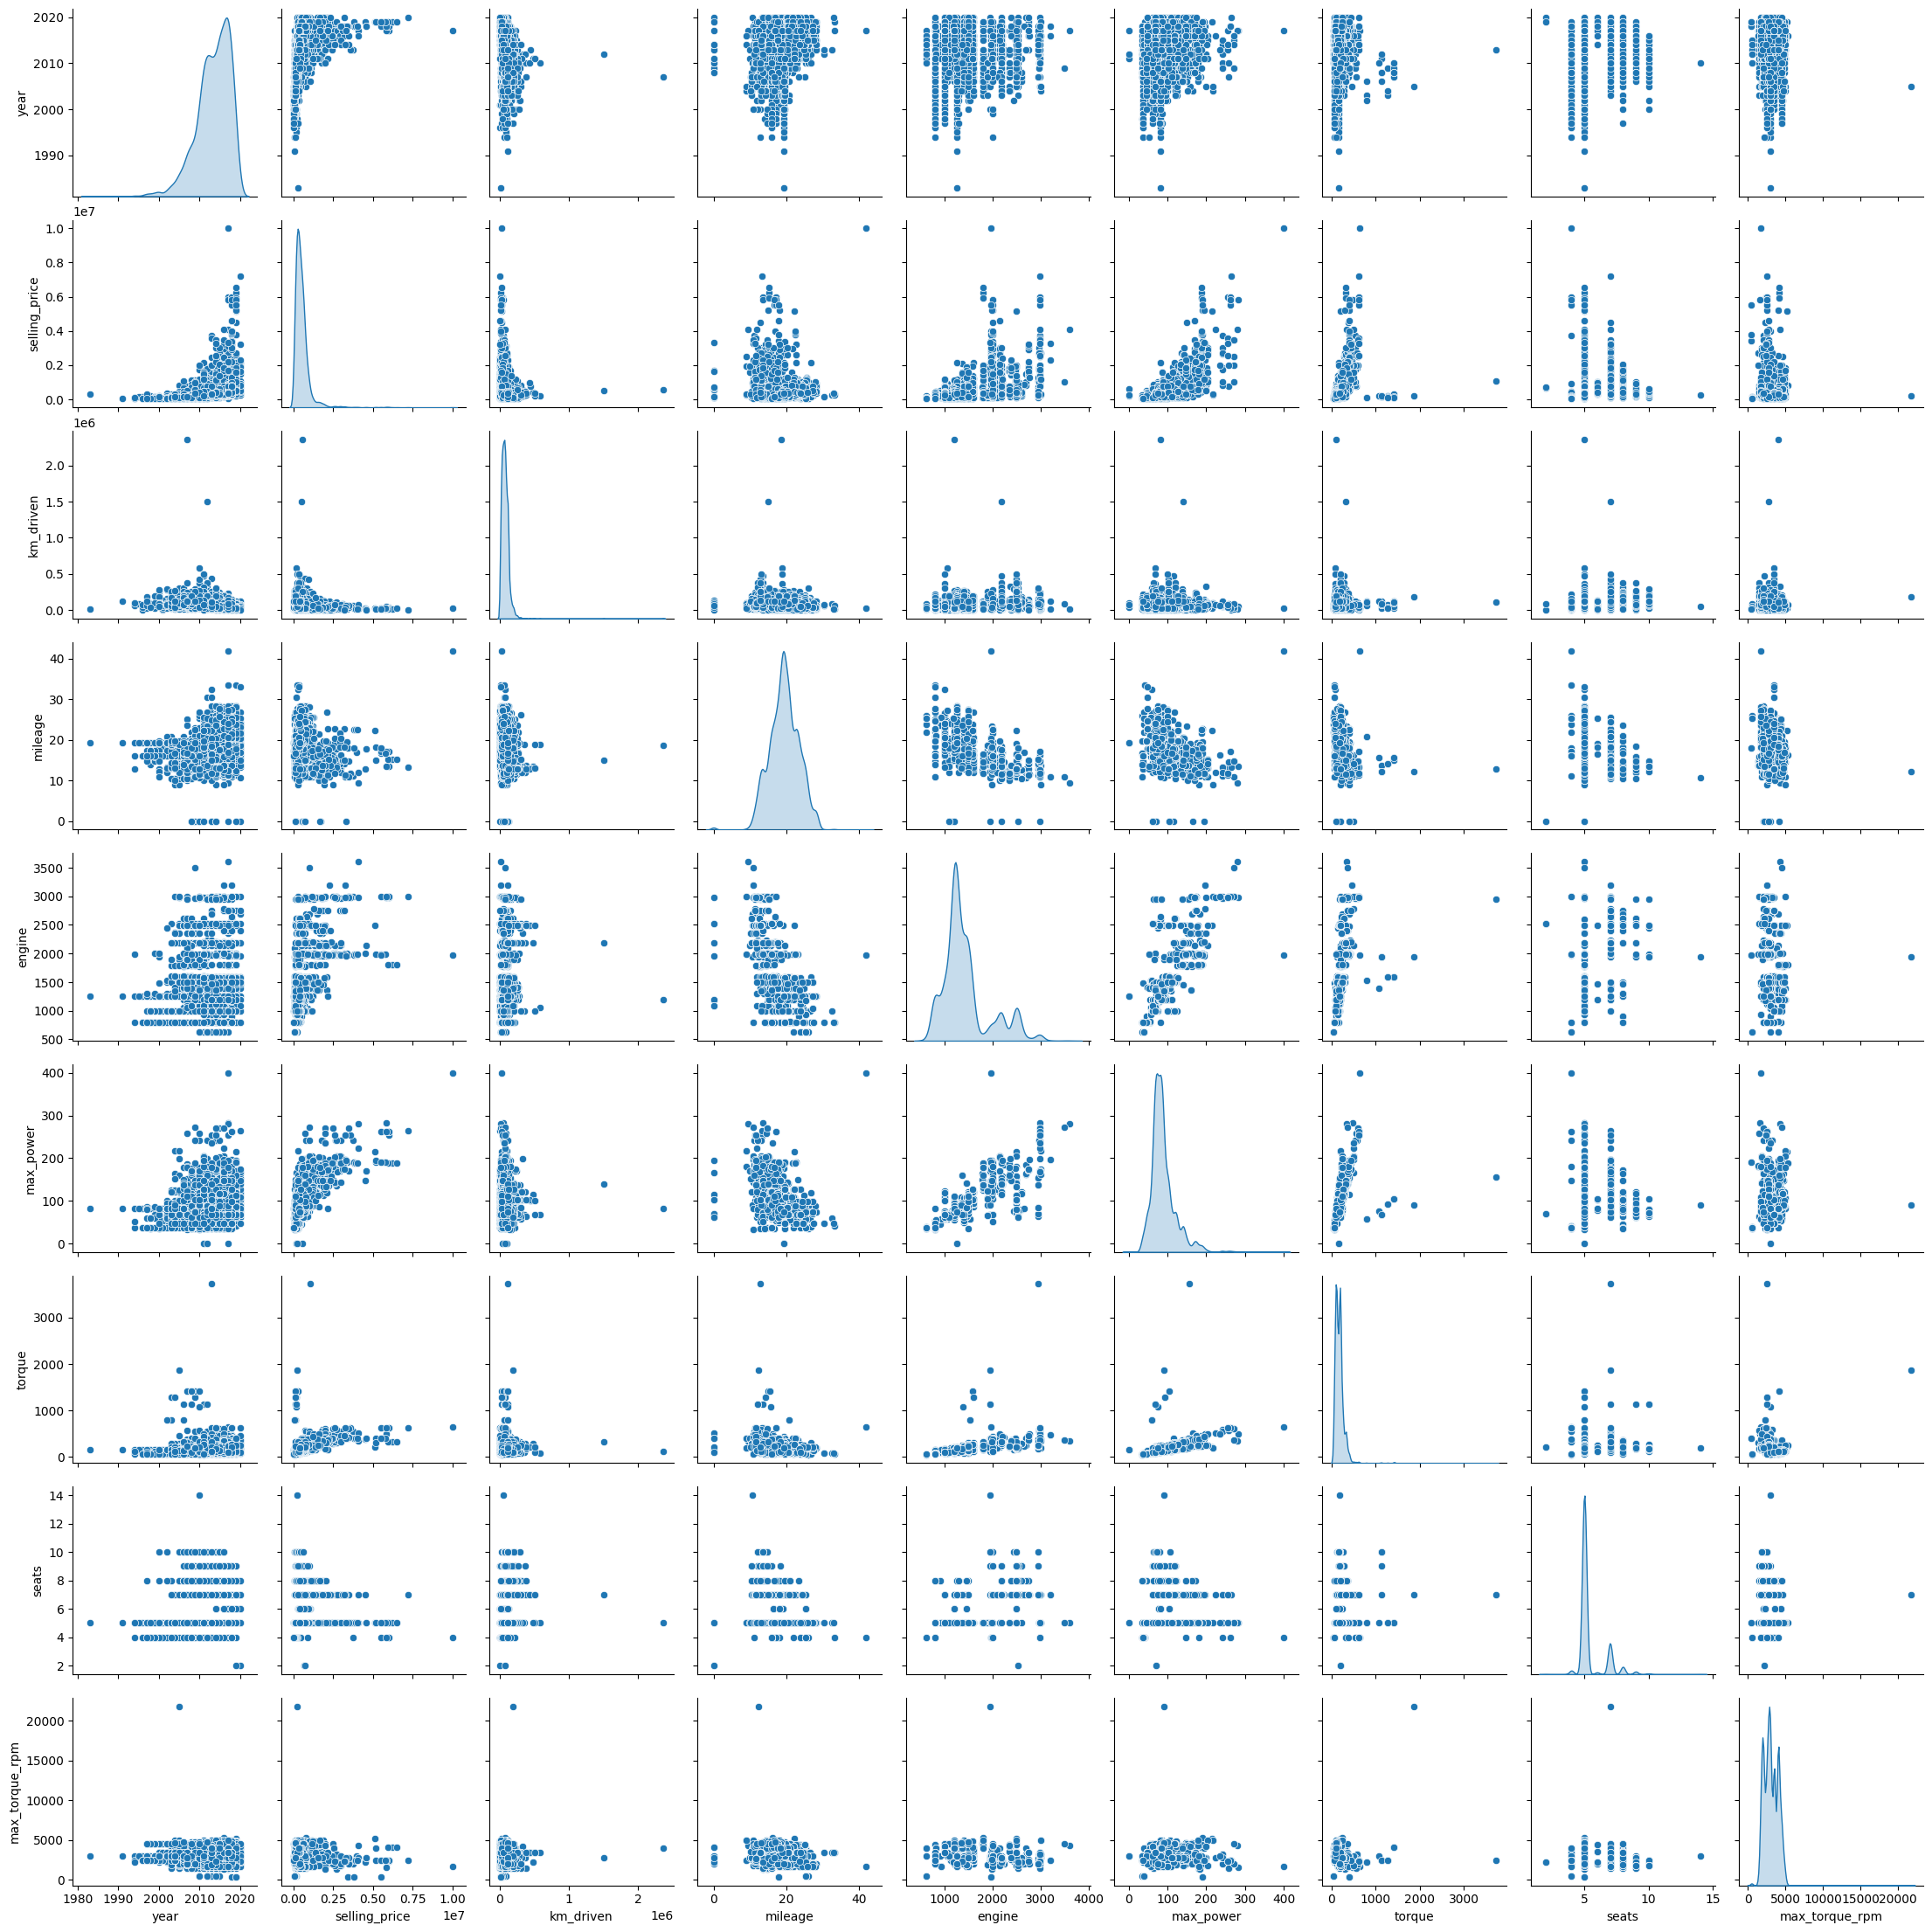

In [170]:
#отбираем числовые признаки и строим pairplot для df_train
numeric_train = df_train.select_dtypes(include='number')
sns.pairplot(numeric_train, diag_kind='kde')
plt.show()

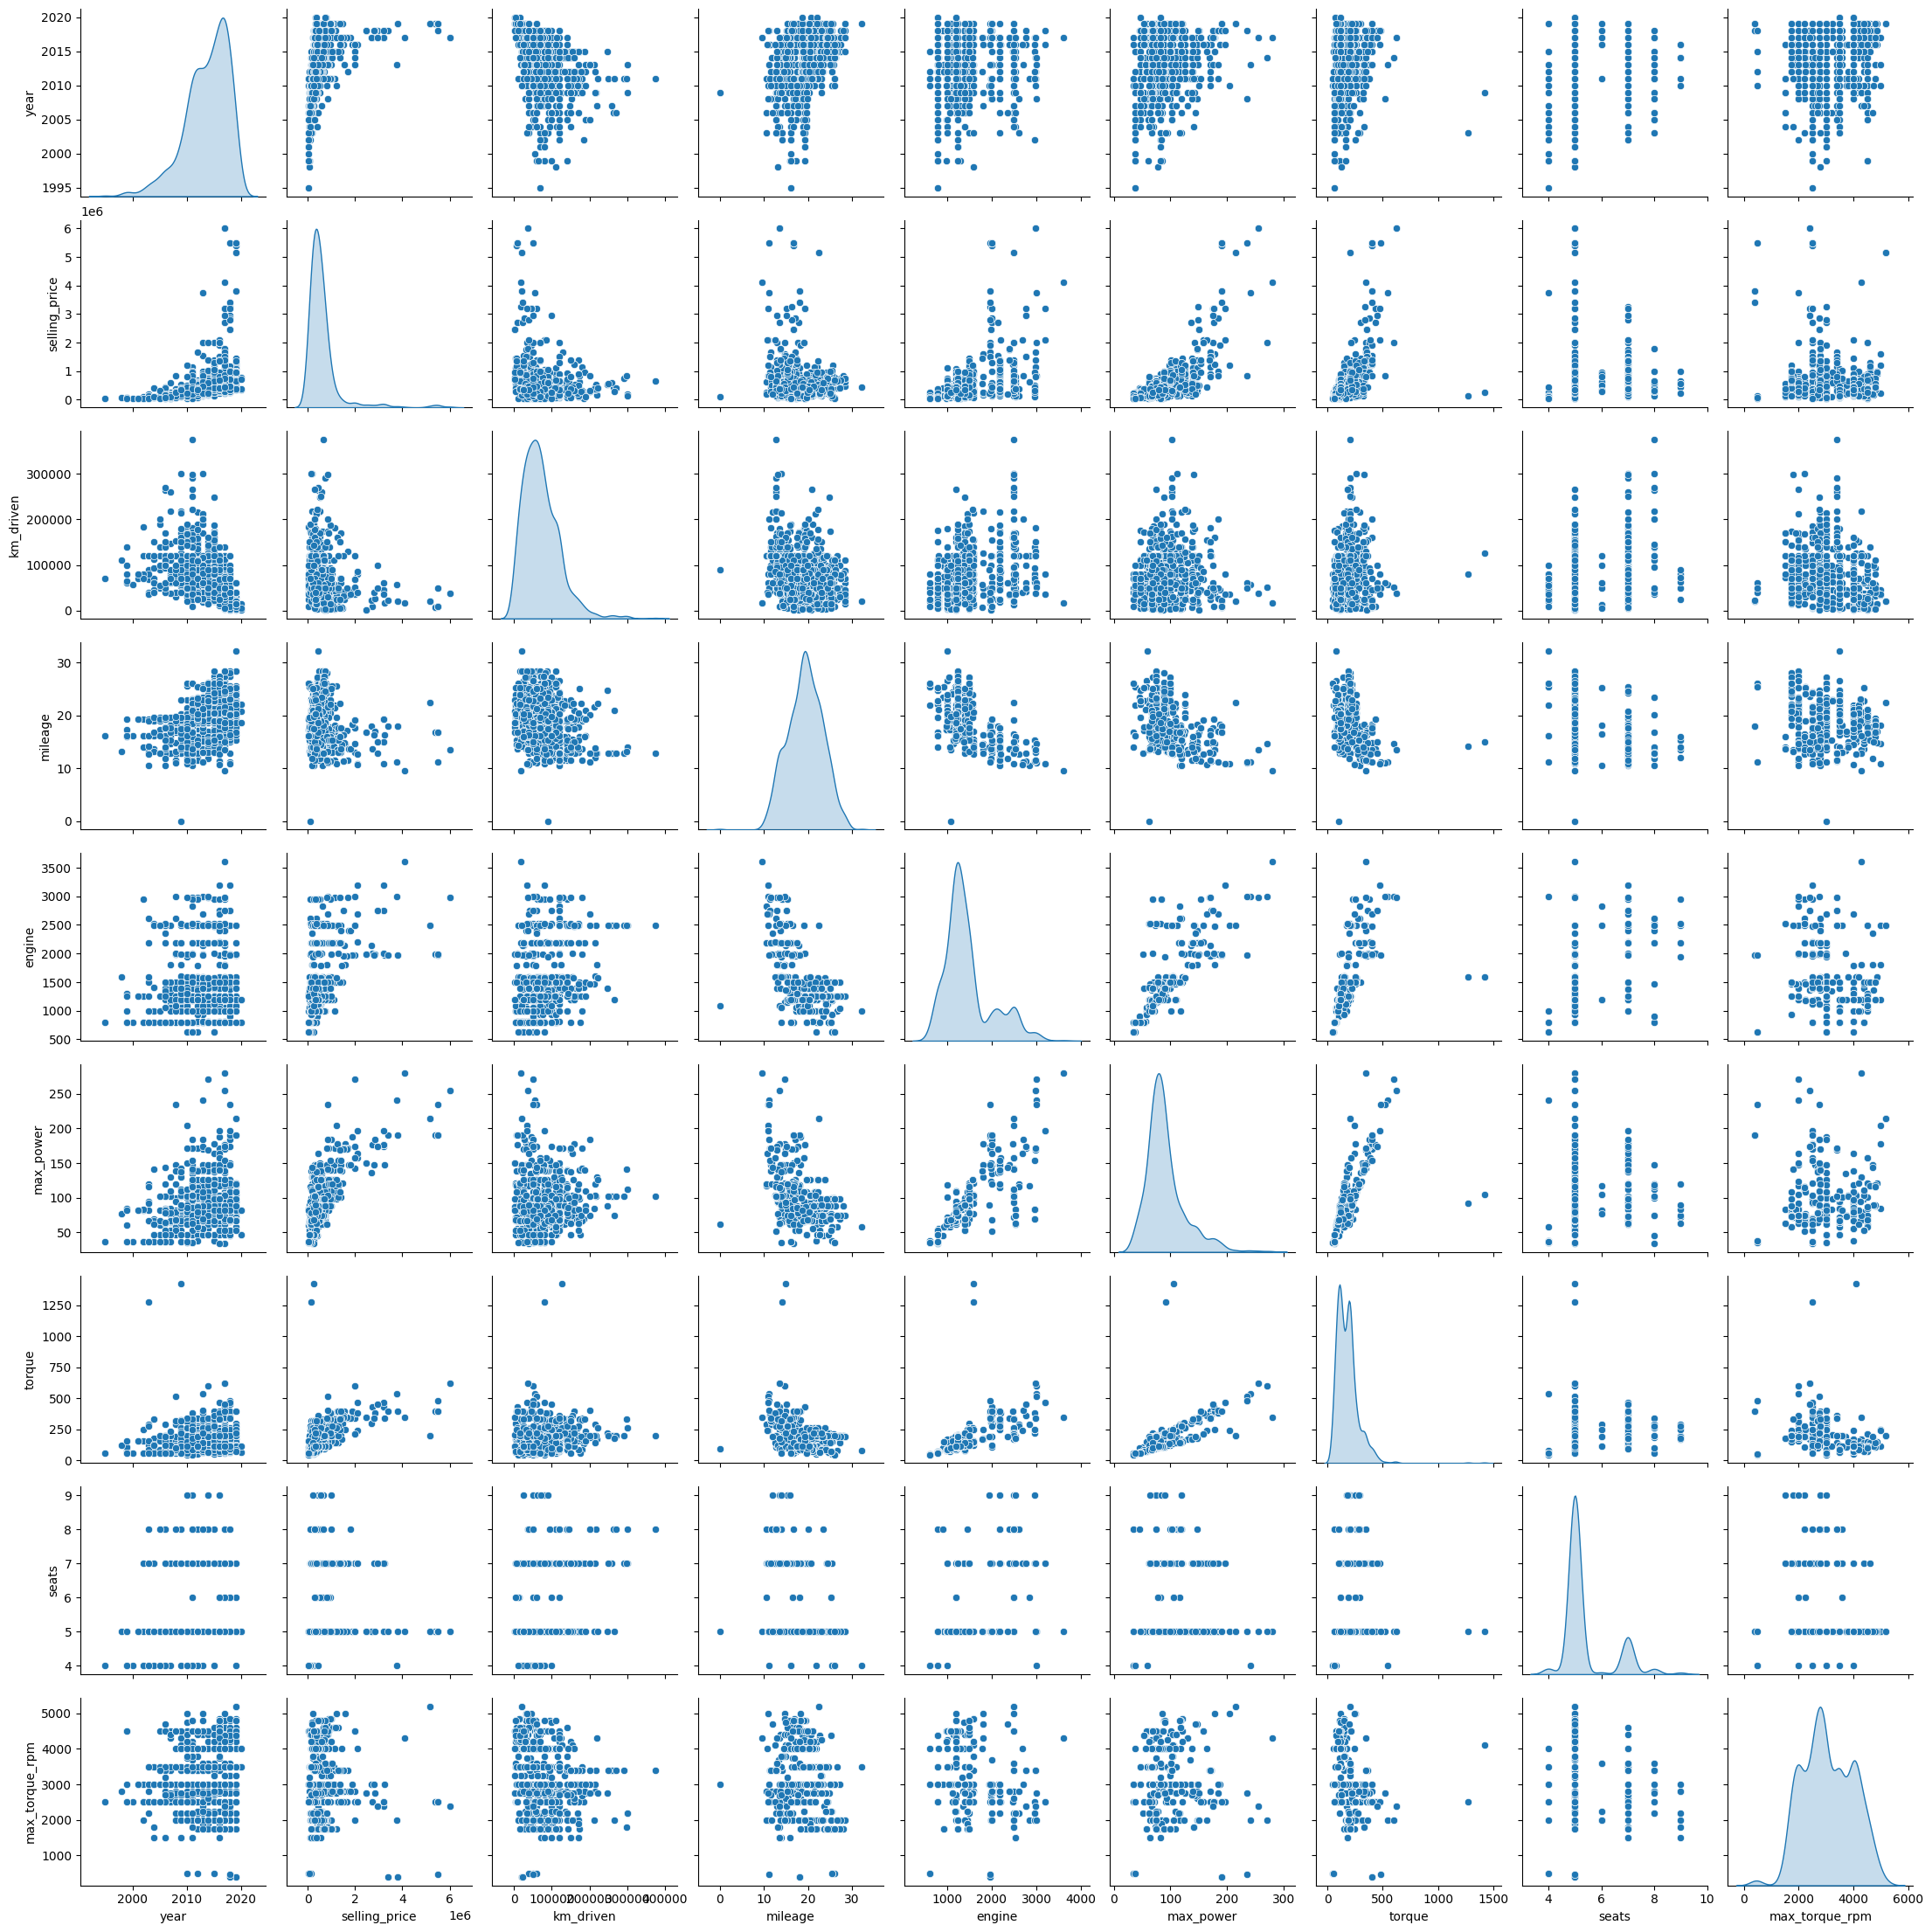

In [171]:
#отбираем числовые признаки и строим pairplot для df_test
numeric_test = df_test.select_dtypes(include='number')

sns.pairplot(numeric_test, diag_kind='kde')
plt.show()

`Целевая переменная сильно связана с мощностью, по графику видна самая выраженная положительная линейная связь, точки выстраиваются почти в возрастающую прямую. А вот у с годом у целевой переменной не очень линейная зависимость, чем больше год (моложе машина), тем выше цена. Также большинство дорогих машин имеют малый пробег. Если смотреть на графики по диагонали, то можно увидеть правосторонние распределения (хвосты справа), мало машин, у которых очень высокая цена или очень большая мощность двигателя. Если сравнивать с тестом, то данные распределены похожим образом, все хорошо `

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

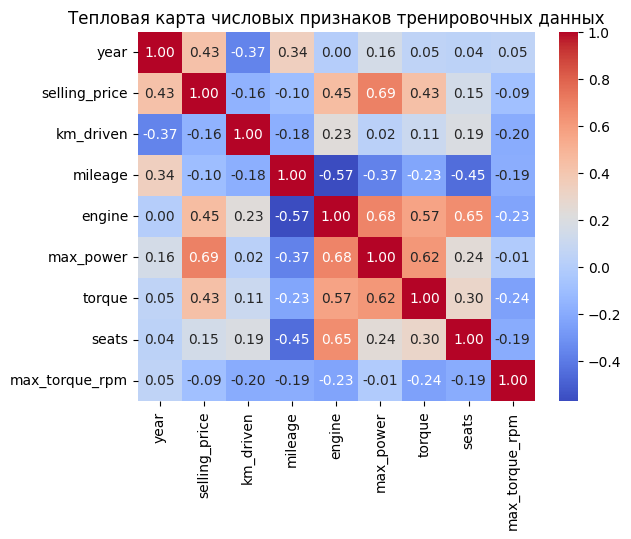

In [172]:
#извлекаем коэффициент Пирсона из numeric_train, в котором содержатся все числовые столбцы из df_train, строим тепловую карту
pearsoner_corr = numeric_train.corr()

sns.heatmap(pearsoner_corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Тепловая карта числовых признаков тренировочных данных')
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

*   Объем двигателя (engine) и год выпуска (year) наименее скоррелированы между собой.
*   Сильная положительная линейная зависимость наблюдается между стоимостью автомобиля (selling_price) и мощностью двигателя (max_power).
*   Да, между пробегом и годом средняя отрицательная линейная связь (-0.37), это значит, что при увеличении одной величины другая уменьшается. Чем старше машина (меньше год), тем больше пробег.

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ]

Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


In [173]:
#вводим функцию, которая будет извлекать отсортированные индексы признаков (ранги), ищем попарно коэффииенты между признаками и заполняем их в матрицу, чтобы красиво вывести результат для df_train
def spearman_corr(x, y):
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))

    return np.corrcoef(rx, ry)[0, 1]

columns = numeric_train.columns
n = len(columns)

spearman_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        x = numeric_train.iloc[:, i].values
        y = numeric_train.iloc[:, j].values
        spearman_matrix[i, j] = spearman_corr(x, y)

my_spearman_df = pd.DataFrame(spearman_matrix, index=columns, columns=columns)

print("Матрица Спирмена с numpy:")
print(my_spearman_df)

print("\nМатрица Спирмена из Pandas:")
print(numeric_train.corr(method='spearman'))

Матрица Спирмена с numpy:
                    year  selling_price  km_driven   mileage    engine  \
year            1.000000       0.705083  -0.567031  0.344179 -0.038301   
selling_price   0.705083       1.000000  -0.295273  0.026304  0.462233   
km_driven      -0.567031      -0.295273   1.000000 -0.198025  0.302698   
mileage         0.344179       0.026304  -0.198025  1.000000 -0.428647   
engine         -0.038301       0.462233   0.302698 -0.428647  1.000000   
max_power       0.165631       0.611807   0.039766 -0.308642  0.711058   
torque          0.106800       0.582751   0.237975 -0.154707  0.835562   
seats           0.045115       0.224200   0.108045 -0.302795  0.354557   
max_torque_rpm  0.076666      -0.120748  -0.314940 -0.182060 -0.363608   

                max_power    torque     seats  max_torque_rpm  
year             0.165631  0.106800  0.045115        0.076666  
selling_price    0.611807  0.582751  0.224200       -0.120748  
km_driven        0.039766  0.237975  0.10

В реализации была помощью со стороны гпт, вообще не в курсе была, как реализован Спирмен изнутри, промпт был "как реализовать Спирмена ручками", но там было что-то сильно сложное, я не смогла понять этот код и мы разобрали, как попарно с помощью цикла обработать признаки и ручками заполнить именно матрицу

interval columns not set, guessing: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']


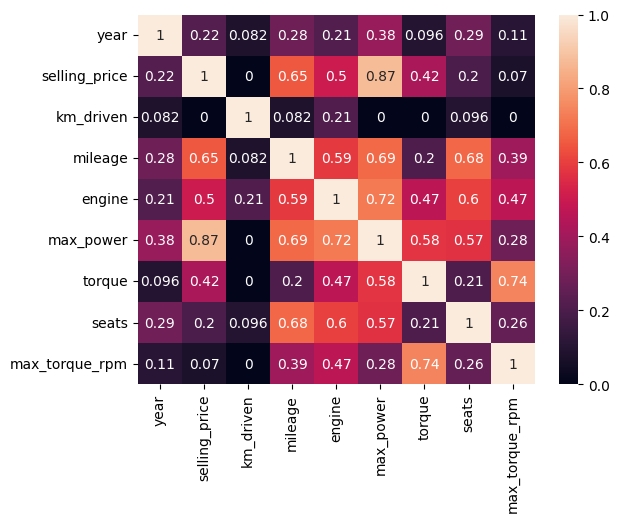

In [174]:
#строим матрицу корреляций phik для df_train
import phik

phik_corr = numeric_train.phik_matrix()

sns.heatmap(phik_corr, annot=True)
plt.show()

`Самая сильная положительная связь у цены с year:  чем новее автомобиль, тем в целом выше его цена. Также заметная положительная связь у цены с max_power: чем выше мощность, тем обычно выше стоимость автомобиля. С km_driven связь отрицательная: это означает, что чем больше пробег, тем ниже цена. С phik все сложнее, немножко противоречит Спирмену, но согласуется с Пирсоном (самый влиятельный признак - мощность", а вот пробег и год не очень влияют, хотя это странно, возможно, данная корреляция чувствительнее к выбросам`

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

In [ ]:
#построим графики по вещественнознчным признакам (тоже убрала вывод, иначе в гите нет предпоказа)

from tqdm.auto import tqdm
columns = numeric_train.columns
n = len(columns)

fig, axes = plt.subplots(nrows=(n // 3) + (n % 3), ncols=3, figsize=(16, (n // 3 + 1) * 7))
for ax, col in tqdm(zip(axes.flatten(), columns)):
    ax.hist(df_train[col], bins=30, alpha=0.7)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid()

for i in range(n, len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.grid()
plt.show()

Подсмотрела в ноутбуке у Ассоль)

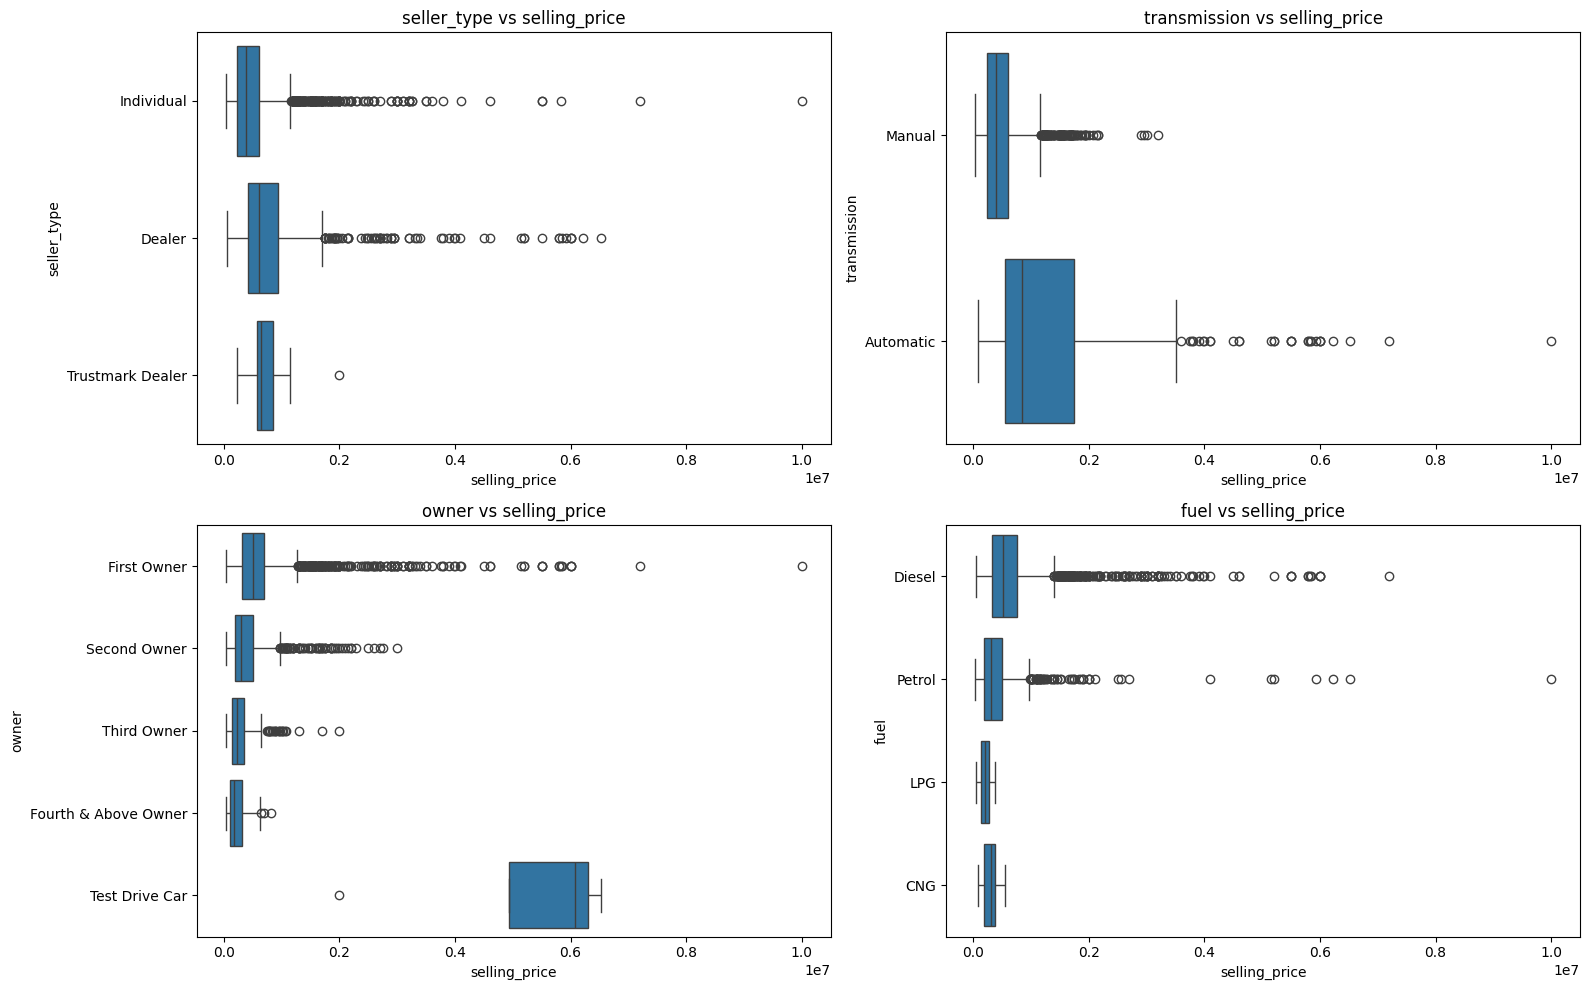

In [176]:
#строим ящики с усами для категориальных признаков

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(x='selling_price', y='seller_type', data=df_train, ax=axes[0, 0])
axes[0, 0].set_title('seller_type vs selling_price')

sns.boxplot(x='selling_price', y='transmission', data=df_train, ax=axes[0, 1])
axes[0, 1].set_title('transmission vs selling_price')

sns.boxplot(x='selling_price', y='owner', data=df_train, ax=axes[1, 0])
axes[1, 0].set_title('owner vs selling_price')

sns.boxplot(x='selling_price', y='fuel', data=df_train, ax=axes[1, 1])
axes[1, 1].set_title('fuel vs selling_price')

plt.tight_layout()
plt.show()


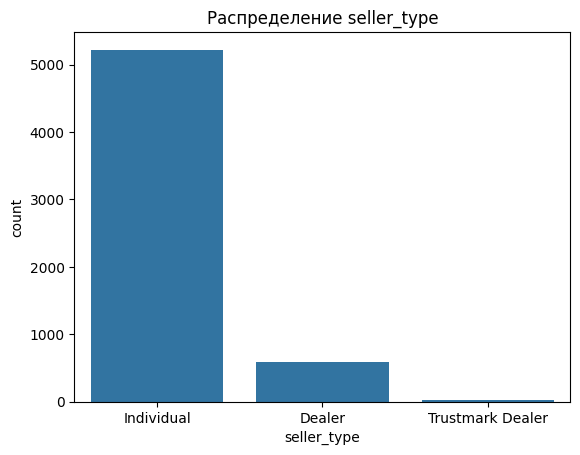

In [177]:
#строим столбчатую диаграмму для seller_type, потому что ранее заметили тут перекос и захотелось оценить масштаб бедствия
sns.countplot(x='seller_type', data=df_train)
plt.title('Распределение seller_type')
plt.show()

Мы уделили мало внимания категориальным признакам, поэтому захотелось и на них посмотреть, чтобы увидеть выбросы, медиану, закономерности

# **Часть 2 (5.4 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [178]:
df_train.shape

(5840, 14)

In [179]:
y_train = numeric_train['selling_price']
X_train = numeric_train.drop('selling_price', axis=1)

In [180]:
assert X_train.shape == (5840, 8)

In [181]:
y_test = numeric_test['selling_price']
X_test = numeric_test.drop('selling_price', axis=1)

In [182]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [183]:
#обучаем линейную регрессию с классическими параметрами и считаем детерминацию и стандратную ошибку для train и для test
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

mse_train = mean_squared_error(y_train, pred_train)
r2_train = r2_score(y_train, pred_train)

mse_test = mean_squared_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

print("Train MSE:", mse_train)
print("Train R2:", r2_train)
print("Test MSE:", mse_test)
print("Test R2:", r2_test)

Train MSE: 113904234704.75421
Train R2: 0.6026203774509138
Test MSE: 226615566164.46033
Test R2: 0.6057684261827156


`Нормально, в целом) Детерминация показывает, что примерно 60% влияния признаков на целевую переменную модель может объяснить, а ошибка такая огромная, потому что целевая переменная - стоимость автомобиля, а ошибка еще и в квадрате`

### **Задание 13 (0.45 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [184]:
R2_train = 1 - (np.sum((y_train - pred_train) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))
print(R2_train)

0.6026203774509138


In [185]:
R2_test = 1 - (np.sum((y_test - pred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
print(R2_test)

0.6057684261827156


$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

*   $y_i$ — истинные значения целевой переменной
*   $\hat{y}_i$ — предсказания модели для целевой переменной
*   $\bar{y}$ — среднее значение целевой переменной
*   $n$ — количество объектов в выборке

В числителе сумма разности истинного значения и предсказания, возведенная в квадрат (чтобы избавиться от отрицательных значений и не обнулить ошибку), в знаменателе сумма разности истинного значения и среднего значения (разброс), тоже возведенная в кважрат по аналогичным причинам.

### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [186]:
n = y_train.shape[0]
p = X_train.shape[1]

R2_train_adjusted = 1 - (1 - R2_train) * (n - 1) / (n - p - 1)

print(R2_train_adjusted)

0.602075181604508


In [187]:
n = y_test.shape[0]
p = X_train.shape[1]

R2_test_adjusted = 1 - (1 - R2_test) * (n - 1) / (n - p - 1)

print(R2_test_adjusted)

0.6025859311367638


`Это "штраф" за большое количество признаков. Применяем, когда хотим посмотреть, достаочно ли признаков. Для этого нужно рассматривать данные с разным количеством признаков, в нашем случае - бесполезно, у нас их и так не очень много, разбивать нет смысла`

### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [188]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr2 = LinearRegression()
lr2.fit(X_train_scaled, y_train)

pred_train2 = lr2.predict(X_train_scaled)
pred_test2 = lr2.predict(X_test_scaled)

print(f'Train MSE после стандартизации: {round(mean_squared_error(y_train, pred_train2), 5)}')
print(f'Train R2 после стандартизации: {round(r2_score(y_train, pred_train2), 5)}')
print(f'Test MSE после стандартизации: {round(mean_squared_error(y_test, pred_test2), 5)}')
print(f'Test R2 после стандартизации: {round(r2_score(y_test, pred_test2), 5)}')


Train MSE после стандартизации: 113904234704.75424
Train R2 после стандартизации: 0.60262
Test MSE после стандартизации: 226615566164.459
Test R2 после стандартизации: 0.60577


`Качество модели практически не изменилось`

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [189]:
print(X_train.columns[np.argmax(np.abs(lr2.coef_))])

max_power


`Мощность двигатела (max_power), это было видно еще по тепловой карте`

### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [190]:
from sklearn.linear_model import Lasso

lr_lasso = Lasso()
lr_lasso.fit(X_train_scaled, y_train)

pred_train3 = lr_lasso.predict(X_train_scaled)
pred_test3 = lr_lasso.predict(X_test_scaled)

print(f'Train MSE после Lasso: {round(mean_squared_error(y_train, pred_train3), 5)}')
print(f'Train R2 после Lasso: {round(r2_score(y_train, pred_train3), 5)}')
print(f'Test MSE после Lasso: {round(mean_squared_error(y_test, pred_test3), 5)}')
print(f'Test R2 после Lasso: {round(r2_score(y_test, pred_test3), 5)}')
print("Количество нулевых коэффициентов:", (lr_lasso.coef_ == 0).sum())

Train MSE после Lasso: 113904234718.34688
Train R2 после Lasso: 0.60262
Test MSE после Lasso: 226616372324.49887
Test R2 после Lasso: 0.60577
Количество нулевых коэффициентов: 0


`Никакие веса не занулились, потому что alpha маленькая по умолчанию, а признаки хорошо связаны с целевой переменной, если увеличить "штраф", то признаки начинают отваливаться, так как веса уже значительно уменьшаются`

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [191]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(3, 5, 20)
searcher = GridSearchCV(Lasso(), [{
    "alpha": alphas
}],
                        scoring="neg_root_mean_squared_error",
                        cv=10)
searcher.fit(X_train_scaled, y_train)

best_alpha_lasso = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha_lasso)

Best alpha = 14384.4989


In [192]:
lr_lasso = Lasso(alpha=14384.4989)
lr_lasso.fit(X_train_scaled, y_train)

pred_train4 = lr_lasso.predict(X_train_scaled)
pred_test4 = lr_lasso.predict(X_test_scaled)

print(f'Train MSE после Lasso: {round(mean_squared_error(y_train, pred_train4), 5)}')
print(f'Train R2 после Lasso: {round(r2_score(y_train, pred_train4), 5)}')
print(f'Test MSE после Lasso: {round(mean_squared_error(y_test, pred_test4), 5)}')
print(f'Test R2 после Lasso: {round(r2_score(y_test, pred_test4), 5)}')
print("Количество нулевых коэффициентов:", (lr_lasso.coef_ == 0).sum())

Train MSE после Lasso: 115108657549.87234
Train R2 после Lasso: 0.59842
Test MSE после Lasso: 237865839971.1001
Test R2 после Lasso: 0.5862
Количество нулевых коэффициентов: 4


*   Всего 20 штук alpha и 10 фолдов, поэтому 200 моделей
*   Alpha – параметр для регуляризации, alphas – массив, откуда будем брать разные значения для alpha, neg_root_mean_squared_error – метрика, которой руководствуется наша модель, она посчитает корень из среднеквадратичной ошибки, возьмет со знаком минус и будет выбирать модель, где это значение наибольшее, то есть наименьшее отклонение, cv – количество фолдов (равных частей), которые получились, когда модель разделила наши тренировочные данные на части
*   Best alpha = 14384.4989. Занулилось 4 признака. Качество модели ухудшилось. Получается, что best_alpha не совсем бест..





**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [193]:
from sklearn.linear_model import ElasticNet

alphas = np.logspace(-2, 3, 20)
l1_ratios = np.linspace(0.1, 0.9, 9)

searcher = GridSearchCV(ElasticNet(), [{
    "alpha": alphas,
    "l1_ratio": l1_ratios
}],
                        scoring="neg_root_mean_squared_error",
                        cv=10)

searcher.fit(X_train_scaled, y_train)

best_alpha_en = searcher.best_params_["alpha"]
best_l1_ratio_en = searcher.best_params_["l1_ratio"]

print("Best alpha = %.4f" % best_alpha_en)
print("Best l1_ratio = %.2f" % best_l1_ratio_en)

Best alpha = 0.0616
Best l1_ratio = 0.20


`Обучено 20 * 10 * 9 = 1800 моделей. Лучшие параметры Best alpha = 0.0616, Best l1_ratio = 0.20`

### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [194]:
def calculate_mse_loss(beta: np.ndarray, samples: np.ndarray, targets: np.ndarray) -> float:
    predictions = samples @ beta
    return np.mean((predictions - targets) ** 2)

def calculate_l0_penalty(beta: np.ndarray) -> int:
    return np.sum(beta[:-1] != 0)

def calculate_total_loss(beta: np.ndarray, samples: np.ndarray, targets: np.ndarray, lmbd: float) -> float:
    mse = calculate_mse_loss(beta, samples, targets)
    l0 = calculate_l0_penalty(beta)
    return mse + lmbd * l0

def add_constant_feature(samples: np.ndarray, beta: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    samples_with_const = np.hstack([samples, np.ones((samples.shape[0], 1))])
    beta_with_const = np.append(beta, 1.0)
    return samples_with_const, beta_with_const

In [195]:
def calculate_gradient(beta: np.ndarray, samples: np.ndarray, targets: np.ndarray) -> np.ndarray:
    diff = samples @ beta - targets
    return (2 / len(targets)) * (samples.T @ diff)

def iteration(beta: np.ndarray, samples: np.ndarray, targets: np.ndarray,
              learning_rate: float, lmbd: float) -> np.ndarray:
    grad = calculate_gradient(beta, samples, targets)
    new_beta = beta - learning_rate * grad

    threshold = np.sqrt(2 * lmbd)
    for i in range(len(new_beta) - 1):
        if abs(new_beta[i]) < threshold:
            new_beta[i] = 0.0

    return new_beta

In [196]:
def learn(samples: np.ndarray, targets: np.ndarray,
          learning_rate: float = 0.001,
          threshold: float = 1e-6,
          max_iter: int = 100000,
          lmbd: float = 0.01):

    samples = np.array(samples)
    targets = np.array(targets).reshape(-1)

    beta = np.ones(samples.shape[1])
    samples, beta = add_constant_feature(samples, beta)

    iteration_loss_dict = {0: calculate_total_loss(beta, samples, targets, lmbd)}

    for itera in range(1, max_iter + 1):
        new_beta = iteration(beta, samples, targets, learning_rate, lmbd)
        new_loss = calculate_total_loss(new_beta, samples, targets, lmbd)
        iteration_loss_dict[itera] = new_loss

        if abs(iteration_loss_dict[itera - 1] - new_loss) < threshold:
            beta = new_beta
            break

        beta = new_beta

    return beta, itera, iteration_loss_dict

In [197]:
def predict(samples: np.ndarray, beta: np.ndarray) -> np.ndarray:
    samples_with_const = np.hstack([samples, np.ones((samples.shape[0], 1))])
    return samples_with_const @ beta

beta, iteration_num, iteration_loss_dict = learn(
    X_train_scaled, y_train, learning_rate=0.01, lmbd=100000
)

pred_train5 = predict(X_train_scaled, beta)
pred_test5 = predict(X_test_scaled, beta)

print(f"Ненулевые веса: {np.sum(beta[:-1] != 0)}")
print("-" * 30)
print(f"Train MSE: {mean_squared_error(y_train, pred_train5):.5f}")
print(f"Train R2:  {r2_score(y_train, pred_train5):.5f}")
print("-" * 30)
print(f"Test MSE:  {mean_squared_error(y_test, pred_test5):.5f}")
print(f"Test R2:   {r2_score(y_test, pred_test5):.5f}")

Ненулевые веса: 7
------------------------------
Train MSE: 113954180254.79958
Train R2:  0.60245
------------------------------
Test MSE:  226890626957.36230
Test R2:   0.60529


Дернула код с градиентным спуском из лабораторной работы №3 и приделала к нему l0 регуляризацию под чутким руководством гпт, промпты был "на каждом шаге градиентного спуска мы обнуляем те веса, которые по модулю меньше определенного порога, как это вписать в мой код?") Пробовала разные параметры, либо очень долго не удавалось занулить хотя бы один вес, либо сразу много. Чем больше весов занулялось, тем хуже себя вела модель

# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [198]:
X_train_cat = df_train.drop('selling_price', axis=1).copy()
X_train_cat['name'] = X_train_cat['name'].str.split().str[0]

X_test_cat = df_test.drop('selling_price', axis=1).copy()
X_test_cat['name'] = X_test_cat['name'].str.split().str[0]

In [199]:
assert X_train_cat.shape == (5840, 13)

In [200]:
X_train_cat.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,30,4,3,2,5
top,Maruti,Diesel,Individual,Manual,First Owner
freq,1804,3177,5223,5336,3603


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [201]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train_cat.select_dtypes(include='object').columns.tolist()
if 'seats' not in cat_cols:
    cat_cols.append('seats')
num_cols = [col for col in X_train_cat.columns if col not in cat_cols]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = ohe.fit_transform(X_train_cat[cat_cols])
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train_cat.index
)
X_train_ready = pd.concat([X_train_cat[num_cols], encoded_train_df], axis=1)

encoded_test = ohe.transform(X_test_cat[cat_cols])
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test_cat.index
)
X_test_ready = pd.concat([X_test_cat[num_cols], encoded_test_df], axis=1)

Реализация взята с последней лекции по pipline и streamlit + доработка с гпт, потому что не удавалось верно оформить всё обратно в датафрейм и взять сидения вместе с категориальными фичами, запрос был "что нужно добавить, чтобы добавить seats к категориальным фичам, как обернуть всё потом в один датафрейм"

### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

*   Кодировать только категориальные признаки, фиксировать порядок и состав столбцов между train/test, для редких категорий использовать категорию "Other".
*   Удаляе столбец для избежания избыточности признаков.
*   Корректно, если признаки не влияют на предсказание (важные, большие веса)

### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [202]:
numeric_train_cat = X_train_ready.select_dtypes(include='number')
numeric_test_cat = X_test_ready.select_dtypes(include='number')

In [203]:
scaler = StandardScaler()

X_train_scaled_cat = scaler.fit_transform(numeric_train_cat)
X_test_scaled_cat = scaler.transform(numeric_test_cat)

lr6 = LinearRegression()
lr6.fit(X_train_scaled_cat, y_train)

pred_train6 = lr6.predict(X_train_scaled_cat)
pred_test6 = lr6.predict(X_test_scaled_cat)

print(f'Train MSE после стандартизации: {round(mean_squared_error(y_train, pred_train6), 5)}')
print(f'Train R2 после стандартизации: {round(r2_score(y_train, pred_train6), 5)}')
print(f'Test MSE после стандартизации: {round(mean_squared_error(y_test, pred_test6), 5)}')
print(f'Test R2 после стандартизации: {round(r2_score(y_test, pred_test6), 5)}')

Train MSE после стандартизации: 64534100917.68455
Train R2 после стандартизации: 0.77486
Test MSE после стандартизации: 121978424960.84894
Test R2 после стандартизации: 0.7878


In [204]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(Ridge(), [{
    "alpha": alphas
}],
                        scoring="r2",
                        cv=10)
searcher.fit(X_train_scaled_cat, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

Best alpha = 545.5595


In [205]:
lr_ridge_best = Ridge(alpha=best_alpha)
lr_ridge_best.fit(X_train_scaled_cat, y_train)

pred_test = lr_ridge_best.predict(X_test_scaled_cat)
mse = mean_squared_error(y_test, pred_test)

pred_train7 = lr_ridge_best.predict(X_train_scaled_cat)
pred_test7 = lr_ridge_best.predict(X_test_scaled_cat)

print(f'Train MSE: {round(mean_squared_error(y_train, pred_train7), 5)}')
print(f'Train R2: {round(r2_score(y_train, pred_train7), 5)}')
print(f'Test MSE: {round(mean_squared_error(y_test, pred_test7), 5)}')
print(f'Test R2: {round(r2_score(y_test, pred_test7), 5)}')

Train MSE: 65537168776.16763
Train R2: 0.77136
Test MSE: 124721549272.4746
Test R2: 0.78303


In [206]:
import joblib
joblib.dump(lr_ridge_best, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

`Да, удалось улучшить качество прогнозов. Детерминация выросла (вместо 60% теперь объясняюся около 80%), а среднеквадратичная ошибка уменьшилась. Везде, где используются модели, коды взяты из ноутбуков к бонусной домашней работе по мл или ноутбука Ассоль с консультаций`

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

In [207]:
X_train_cat_new = df_train.drop('selling_price', axis=1).copy()

name_parts = X_train_cat_new['name'].str.split()

X_train_cat_new['brand'] = name_parts.str[0].fillna('unknown')
X_train_cat_new['model'] = name_parts.str[1].fillna('unknown')
X_train_cat_new['version'] = name_parts.str[2:].str.join(' ').fillna('standard')

X_train_cat_new = X_train_cat_new.drop('name', axis=1)

In [208]:
top_version_count = 10

top_versions = X_train_cat_new['version'].value_counts().nlargest(top_version_count).index

X_train_cat_new.loc[~X_train_cat_new['version'].isin(top_versions), 'version'] = 'other'

In [209]:
cat_cols = X_train_cat_new.select_dtypes(include='object').columns.tolist()

if 'seats' not in cat_cols and 'seats' in X_train_cat_new.columns:
    cat_cols.append('seats')

num_cols = [col for col in X_train_cat_new.columns if col not in cat_cols]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = ohe.fit_transform(X_train_cat_new[cat_cols])

encoded_train_df_new = pd.DataFrame(
    encoded_train,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train_cat_new.index
)

X_train_ready_new = pd.concat([X_train_cat_new[num_cols], encoded_train_df_new], axis=1)

In [210]:
numeric_train_cat_new = X_train_ready_new.select_dtypes(include='number')

In [211]:
scaler = StandardScaler()

X_train_scaled_cat_new = scaler.fit_transform(numeric_train_cat_new)

In [212]:
alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(Ridge(), [{
    "alpha": alphas
}],
                        scoring="r2",
                        cv=10)
searcher.fit(X_train_scaled_cat_new, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

Best alpha = 297.6351


In [213]:
lr_ridge_best = Ridge(alpha=best_alpha)
lr_ridge_best.fit(X_train_scaled_cat_new, y_train)

pred_train_new = lr_ridge_best.predict(X_train_scaled_cat_new)

print(f'Train MSE: {round(mean_squared_error(y_train, pred_train7), 5)}')
print(f'Train R2: {round(r2_score(y_train, pred_train7), 5)}')

Train MSE: 65537168776.16763
Train R2: 0.77136


`Ничего не поменялось) Но это и логично, ведь модель машины не сильно влияет на ценообразование, больше влияет бренд и характеристики, а версия содержит информацию о каком-то дополнении в машине, которое тоже уже есть в других признаках. А так хотелось просто глянуть, не зря ли мы в name оставили только марку машины. Получается, не зря)`

# **Часть 4. | Бизнесовая (1.5 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

In [214]:
def business_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    error = np.abs((y_pred - y_true) / y_true)
    return np.mean(error <= 0.1)
business_metrics(y_train, pred_train)

np.float64(0.22226027397260273)

In [215]:
business_metrics(y_train, pred_train2)

np.float64(0.22226027397260273)

In [216]:
business_metrics(y_train, pred_train3)

np.float64(0.22226027397260273)

In [217]:
business_metrics(y_train, pred_train4)

np.float64(0.22397260273972602)

In [218]:
business_metrics(y_train, pred_train5)

np.float64(0.2232876712328767)

In [219]:
business_metrics(y_train, pred_train6)

np.float64(0.27842465753424656)

In [220]:
business_metrics(y_train, pred_train7)

np.float64(0.2803082191780822)

`Последняя (где перекодировали категориальные фичи и добавили их к числовыми) наиболее удачная,  ~28% прогнозов на трейне укладываются в ±10% от настоящей цены`

### **Задание 24 (0.75 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



In [221]:
def your_business_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    error = (y_pred - y_true) / y_true

    return np.mean((error <= 0.1) & (error >= -0.05))

business_metrics(y_train, pred_train)

np.float64(0.22226027397260273)

Не очень у меня с решением бизнес-задач, просто подумала, что код будет такой же, как в прошлом случае, только теперь запрещаем ошибаться в сторону "недопрогноза" в меньшей мере, чем в сторону "перепрогноза"

In [222]:
your_business_metrics(y_train, pred_train2)

np.float64(0.16523972602739725)

In [223]:
your_business_metrics(y_train, pred_train3)

np.float64(0.16523972602739725)

In [224]:
your_business_metrics(y_train, pred_train4)

np.float64(0.1625)

In [225]:
your_business_metrics(y_train, pred_train5)

np.float64(0.16678082191780821)

In [226]:
your_business_metrics(y_train, pred_train6)

np.float64(0.20599315068493151)

In [227]:
your_business_metrics(y_train, pred_train7)

np.float64(0.20941780821917808)

`Лучше всего справилась первая модель, классическая линейная рергрессия только на вещественных признаках с дефолтными параметрами`

# **Часть 5 (12 баллов) | Создание интерактивного приложения на Streamlit**

### **Задание 25 (9 баллов)**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (3 балла)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (3 балла)
- Визуализировать веса обученной модели (3 балла)

Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

Приложила ссылку на приложение + демо, где записано видео со всеми вкладками

### **Задание 26 (3 балла). Оформление результатов**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории.

Под результатами понимаем следующее:

---

#### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```
5. **заполненный requirements.txt**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.

**Также необходимо приложить ссылку на развернутое в StreamlitHub приложение.**


### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном
* слабая или неполная аналитика в `.md`-файле
* беспорядок в ноутбуке или неясная логика вычислений
* отсутствие файлов
* невыполнение любых других обязательных требований, указанных в описании задания
* Streamlit-приложение не развернуто / не запускается

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

    Лучше бы после каждой лекции были менее масштабные домашки на отработку чего-то одного, а вот такие сборные солянки - как проекты (итоговая домашка). Есть ощущение, что я ничего не запоминаю, потому что нет времени отработать отдельно качественно всё. Вот тут, например, очень хотелось бы с пайплайнами и стримлитом разобраться, но потратила два дня на попытки запуститься без ошибок только своими силами, на нормальное выполнение бонуса времени и сил не хватило, как и на разобраться с каждой моделью отдельно, поглядеть, что у нее под капотом происходит. Скорее "эгегей, считай, машинка" :(

P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!